In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

print(f"TensorFlow version : {tf.__version__}")
print(" packages loaded successfully!")


TensorFlow version : 2.19.0
 packages loaded successfully!


In [9]:
# ── Dataset Paths ──
TRAIN_DIR = "/content/drive/MyDrive/FinalDataSet/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train/"
TEST_DIR  = "/content/drive/MyDrive/FinalDataSet/devnagari_dataset/DevanagariHandwrittenDigitDataset/Test/"

# Image dimensions (consistent shape as instructed)
IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10
print(f"   Training: {TRAIN_DIR}")
print(f"   Testing:  {TEST_DIR}")
print(f"   Image size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"   Classes: {NUM_CLASSES} (digits 0-9)")

   Training: /content/drive/MyDrive/FinalDataSet/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train/
   Testing:  /content/drive/MyDrive/FinalDataSet/devnagari_dataset/DevanagariHandwrittenDigitDataset/Test/
   Image size: 28x28
   Classes: 10 (digits 0-9)


In [10]:
def load_images_from_folder(folder):
    """
    Loads images and labels from a folder structured as:
        folder/class_name/image_file

    Steps:
        1. Read each class sub-folder (sorted for consistency).
        2. Open each image with PIL, convert to grayscale.
        3. Resize to (IMG_HEIGHT, IMG_WIDTH).
        4. Normalize pixel values to [0, 1].
        5. Append image array and integer label.

    Returns:
        images (np.ndarray): shape (N, 28, 28)
        labels (np.ndarray): shape (N,)  — integer class indices
    """
    images = []
    labels = []

    # Sort class names so label indices are deterministic
    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}

    print(f"Found {len(class_names)} classes in '{folder}': {class_names}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")                # grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))              # resize to 28×28
                img = np.array(img, dtype=np.float32) / 255.0         # normalize → [0,1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"  [WARNING] Could not load {img_path}: {e}")

    return np.array(images), np.array(labels)

In [12]:
# ── Load Training and Testing Datasets ──
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)
x_test_raw,  y_test_raw  = load_images_from_folder(TEST_DIR)

print(f"\nRaw training set : {x_train_raw.shape}  |  Labels: {y_train_raw.shape}")
print(f"Raw testing set  : {x_test_raw.shape}   |  Labels: {y_test_raw.shape}")

Found 10 classes in '/content/drive/MyDrive/FinalDataSet/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train/': ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Found 10 classes in '/content/drive/MyDrive/FinalDataSet/devnagari_dataset/DevanagariHandwrittenDigitDataset/Test/': ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']

Raw training set : (17000, 28, 28)  |  Labels: (17000,)
Raw testing set  : (3000, 28, 28)   |  Labels: (3000,)


In [13]:
# ── Flatten images for FCN input: (N, 28, 28) → (N, 784) ──
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)   # (N, 784)
x_test  = x_test_raw.reshape(-1,  IMG_HEIGHT * IMG_WIDTH)   # (N, 784)

# ── One-hot encode labels ──
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"x_train shape : {x_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"x_test  shape : {x_test.shape}")
print(f"y_test  shape : {y_test.shape}")

x_train shape : (17000, 784)
y_train shape : (17000, 10)
x_test  shape : (3000, 784)
y_test  shape : (3000, 10)


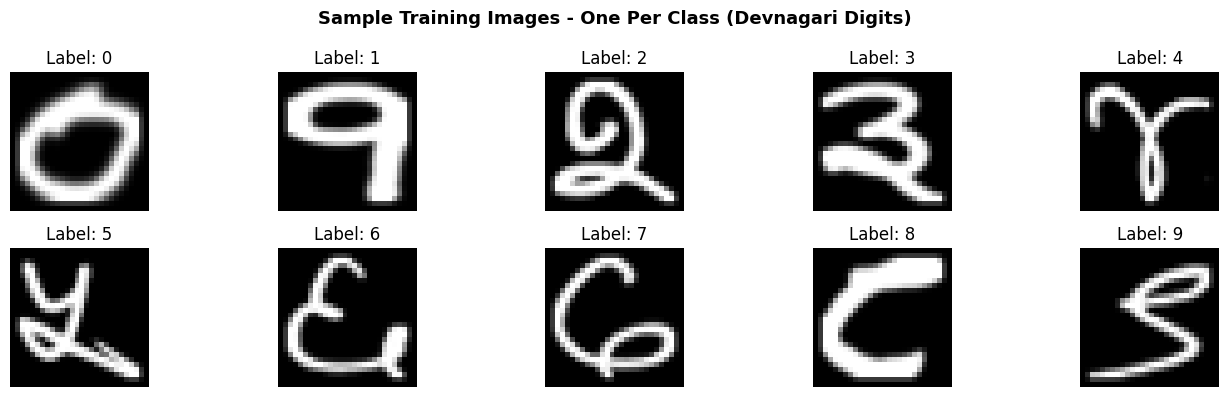

In [14]:
# ── Visualise ONE sample from EACH class ──
plt.figure(figsize=(14, 4))

# Find one example of each digit (0-9)
displayed = []
for digit in range(10):
    # Find first occurrence of this digit
    idx = np.where(y_train_raw == digit)[0][0]
    displayed.append(idx)

    plt.subplot(2, 5, digit + 1)
    plt.imshow(x_train_raw[idx], cmap='gray')
    plt.title(f"Label: {digit}")
    plt.axis('off')

plt.suptitle("Sample Training Images - One Per Class (Devnagari Digits)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Task 2: Build the FCN Model

Architecture (Sequential API):
- **Flatten** layer → converts 784-dim input
- **Hidden Layer 1:** 64 neurons, sigmoid activation
- **Hidden Layer 2:** 128 neurons, sigmoid activation
- **Hidden Layer 3:** 256 neurons, sigmoid activation
- **Output Layer:** 10 neurons, softmax activation

In [15]:
model = keras.Sequential([
    keras.layers.Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),
    keras.layers.Dense(64,  activation='relu', name='hidden_1'),
    keras.layers.Dense(128, activation='relu', name='hidden_2'),
    keras.layers.Dense(256, activation='relu', name='hidden_3'),
    keras.layers.Dense(NUM_CLASSES, activation='softmax', name='output'),
], name="FCN_Devnagari")


---
## Task 3: Compile the Model

- **Optimizer:** Adam
- **Loss Function:** Categorical Crossentropy (since labels are one-hot encoded)
- **Metric:** Accuracy

In [16]:
# ── Compile the Model ──
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"  Optimizer : Adam")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled successfully!
  Optimizer : Adam
  Loss      : categorical_crossentropy
  Metrics   : accuracy


---
## Task 4: Train the Model

- **Batch size:** 128
- **Epochs:** 20
- **Validation split:** 20%
- **Callbacks:** ModelCheckpoint + EarlyStopping

In [17]:
# ── Training Parameters ──
BATCH_SIZE       = 128
EPOCHS           = 20
VALIDATION_SPLIT = 0.2    # 20% of training data used for validation

# ── Callbacks ──
callbacks = [
    # Save the best model (lowest val_loss) during training
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # Stop training early if val_loss doesn't improve for 5 consecutive epochs
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

print(f"Training config:")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Max epochs       : {EPOCHS}")
print(f"  Validation split : {int(VALIDATION_SPLIT * 100)}%")

Training config:
  Batch size       : 128
  Max epochs       : 20
  Validation split : 20%


In [18]:
# ── Train the Model ──
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6842 - loss: 1.0239
Epoch 1: val_loss improved from None to 14.28463, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8376 - loss: 0.5295 - val_accuracy: 0.0000e+00 - val_loss: 14.2846
Epoch 2/20
 92/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9482 - loss: 0.1645
Epoch 2: val_loss did not improve from 14.28463
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9573 - loss: 0.1382 - val_accuracy: 0.0000e+00 - val_loss: 15.3032
Epoch 3/20
 89/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9747 - loss: 0.0865
Epoch 3: val_loss did not improve from 14.28463
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9747 - loss: 0.0843 - val_accuracy: 0.0000e+00 - val_loss: 15.9217
Epoch 4/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9799 - loss: 0.0647
Epoch 4: val_loss did not improve fro

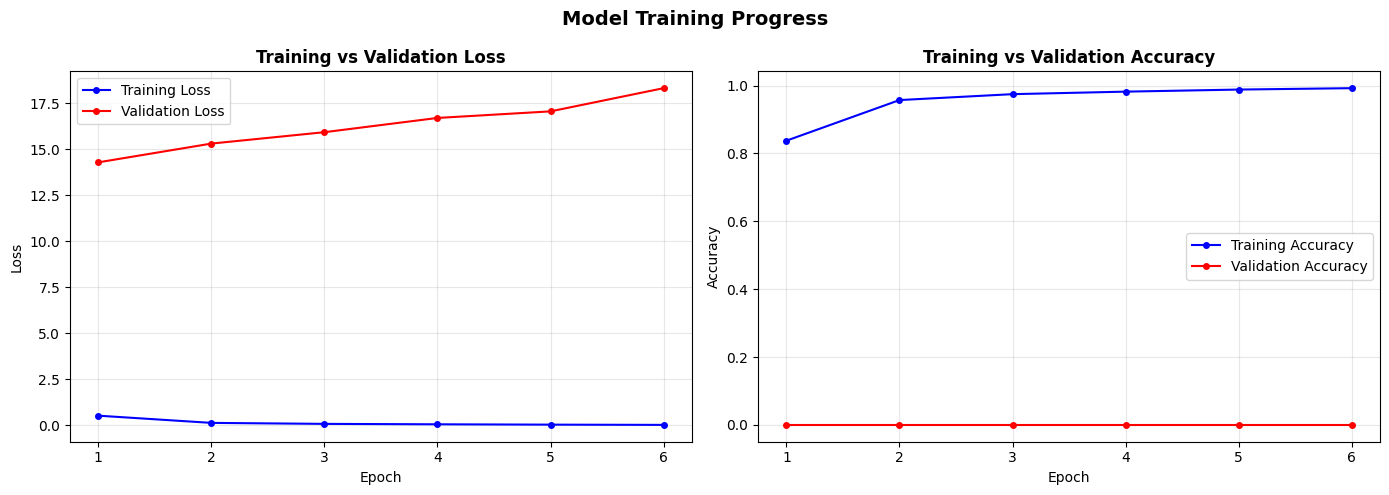

In [19]:
# ── Visualise Training Progress ──
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_loss, 'b-o', markersize=4, label='Training Loss')
plt.plot(epochs_ran, val_loss,   'r-o', markersize=4, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs_ran, train_acc, 'b-o', markersize=4, label='Training Accuracy')
plt.plot(epochs_ran, val_acc,   'r-o', markersize=4, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Model Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 5: Evaluate the Model

Evaluate the trained model on the **test set** to check final accuracy and loss.

In [20]:
# ── Evaluate on Test Set ──
print("Evaluating model on test set...\n")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)")
print(f"{'='*40}")

Evaluating model on test set...

94/94 - 1s - 14ms/step - accuracy: 0.7473 - loss: 2.9968

  Test Loss     : 2.9968
  Test Accuracy : 0.7473  (74.73%)


---
## Task 6: Save and Load the Model

Save the trained model to a `.h5` file, then reload it and re-evaluate.

In [22]:
# ── Save the Model ──
# ✅ CORRECT - Raw string ignores escape sequences
MODEL_PATH = r'C:\Users\acer\Desktop\FInalYearAI\Week4\Models\devnagari_fcnn_model.h5'


model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

Model saved to: C:\Users\acer\Desktop\FInalYearAI\Week4\Models\devnagari_fcnn_model.h5


In [23]:
# ── Load the Saved Model ──
loaded_model = tf.keras.models.load_model(MODEL_PATH)
print(f"Model loaded from: {MODEL_PATH}")
loaded_model.summary()

Model loaded from: C:\Users\acer\Desktop\FInalYearAI\Week4\Models\devnagari_fcnn_model.h5


Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,156 (367.80 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [24]:
# ── Re-evaluate the Loaded Model ──
print("Re-evaluating the loaded model on test set...\n")
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"  Loaded Model Test Accuracy : {loaded_acc:.4f}  ({loaded_acc * 100:.2f}%)")
print(f"{'='*40}")

Re-evaluating the loaded model on test set...

94/94 - 1s - 12ms/step - accuracy: 0.7473 - loss: 2.9968

  Loaded Model Test Loss     : 2.9968
  Loaded Model Test Accuracy : 0.7473  (74.73%)


---
## Task 7: Making Predictions

Use `model.predict()` on the test set, convert probability outputs to digit labels using `np.argmax()`, and visualise results.

In [27]:
# ── Make Predictions ──
print("Generating predictions on test set...")
predictions = loaded_model.predict(x_test, verbose=0)

# Convert predicted probability distributions to class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

print(f"Predictions shape : {predictions.shape}")

# Show one example from each digit class (0-9)
print("\nPredictions for each digit class:")
for digit in range(10):
    idx = np.where(true_labels == digit)[0][0]  # Find first occurrence
    print(f"Digit {digit}: Predicted={predicted_labels[idx]}, True={true_labels[idx]}")


Generating predictions on test set...
Predictions shape : (3000, 10)

Predictions for each digit class:
Digit 0: Predicted=0, True=0
Digit 1: Predicted=1, True=1
Digit 2: Predicted=2, True=2
Digit 3: Predicted=3, True=3
Digit 4: Predicted=4, True=4
Digit 5: Predicted=5, True=5
Digit 6: Predicted=6, True=6
Digit 7: Predicted=7, True=7
Digit 8: Predicted=0, True=8
Digit 9: Predicted=1, True=9


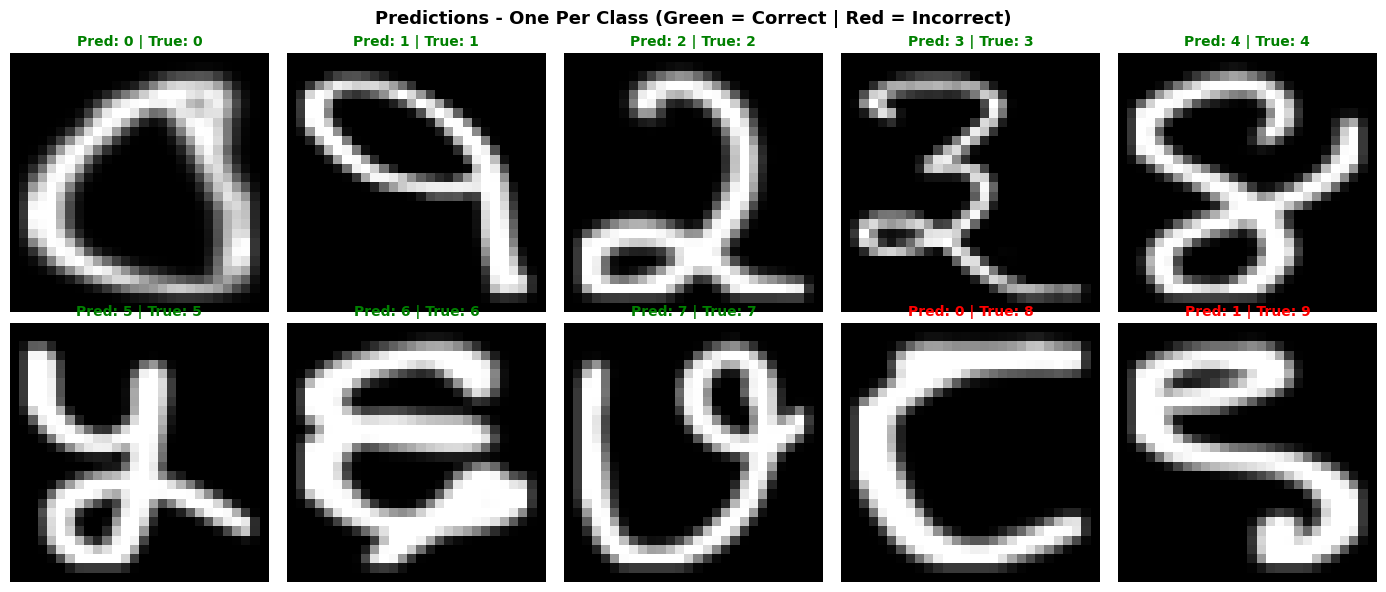

In [29]:
# ── Visualise Predictions — One from Each Class ──
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for digit in range(10):
    idx = np.where(true_labels == digit)[0][0]  # Find first occurrence of each digit

    img   = x_test_raw[idx]
    pred  = predicted_labels[idx]
    true  = true_labels[idx]
    color = 'green' if pred == true else 'red'

    axes[digit].imshow(img, cmap='gray')
    axes[digit].set_title(f"Pred: {pred} | True: {true}",
                          color=color, fontsize=10, fontweight='bold')
    axes[digit].axis('off')

plt.suptitle('Predictions - One Per Class (Green = Correct | Red = Incorrect)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [30]:
# ── Per-class Accuracy Breakdown ──
print("Per-class Accuracy:\n")
print(f"{'Class':<10} {'Correct':>10} {'Total':>10} {'Accuracy':>12}")
print("-" * 46)

for cls in range(NUM_CLASSES):
    mask    = (true_labels == cls)
    correct = np.sum(predicted_labels[mask] == cls)
    total   = np.sum(mask)
    acc     = correct / total if total > 0 else 0
    print(f"digit_{cls:<4}  {correct:>10}  {total:>10}  {acc * 100:>10.2f}%")

print("-" * 46)
overall = np.sum(predicted_labels == true_labels) / len(true_labels)
print(f"{'Overall':<10} {np.sum(predicted_labels == true_labels):>10}  {len(true_labels):>10}  {overall * 100:>10.2f}%")

Per-class Accuracy:

Class         Correct      Total     Accuracy
----------------------------------------------
digit_0            284         300       94.67%
digit_1            293         300       97.67%
digit_2            234         300       78.00%
digit_3            281         300       93.67%
digit_4            290         300       96.67%
digit_5            289         300       96.33%
digit_6            275         300       91.67%
digit_7            296         300       98.67%
digit_8              0         300        0.00%
digit_9              0         300        0.00%
----------------------------------------------
Overall          2242        3000       74.73%


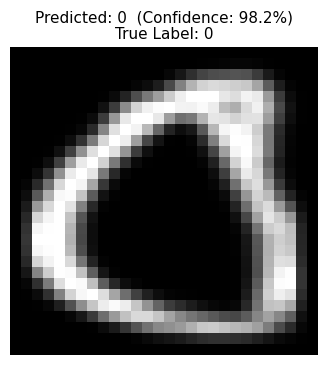

Predicted label : 0
True label      : 0
Confidence      : 98.17%


In [31]:
# ── Single Image Prediction Demo ──
sample_idx = 0
sample_img = x_test[sample_idx].reshape(1, -1)   # shape (1, 784)

single_pred  = loaded_model.predict(sample_img, verbose=0)
pred_label   = np.argmax(single_pred)
true_label   = true_labels[sample_idx]
confidence   = np.max(single_pred) * 100

plt.figure(figsize=(4, 4))
plt.imshow(x_test_raw[sample_idx], cmap='gray')
plt.title(
    f"Predicted: {pred_label}  (Confidence: {confidence:.1f}%)\nTrue Label: {true_label}",
    fontsize=11
)
plt.axis('off')
plt.show()

print(f"Predicted label : {pred_label}")
print(f"True label      : {true_label}")
print(f"Confidence      : {confidence:.2f}%")